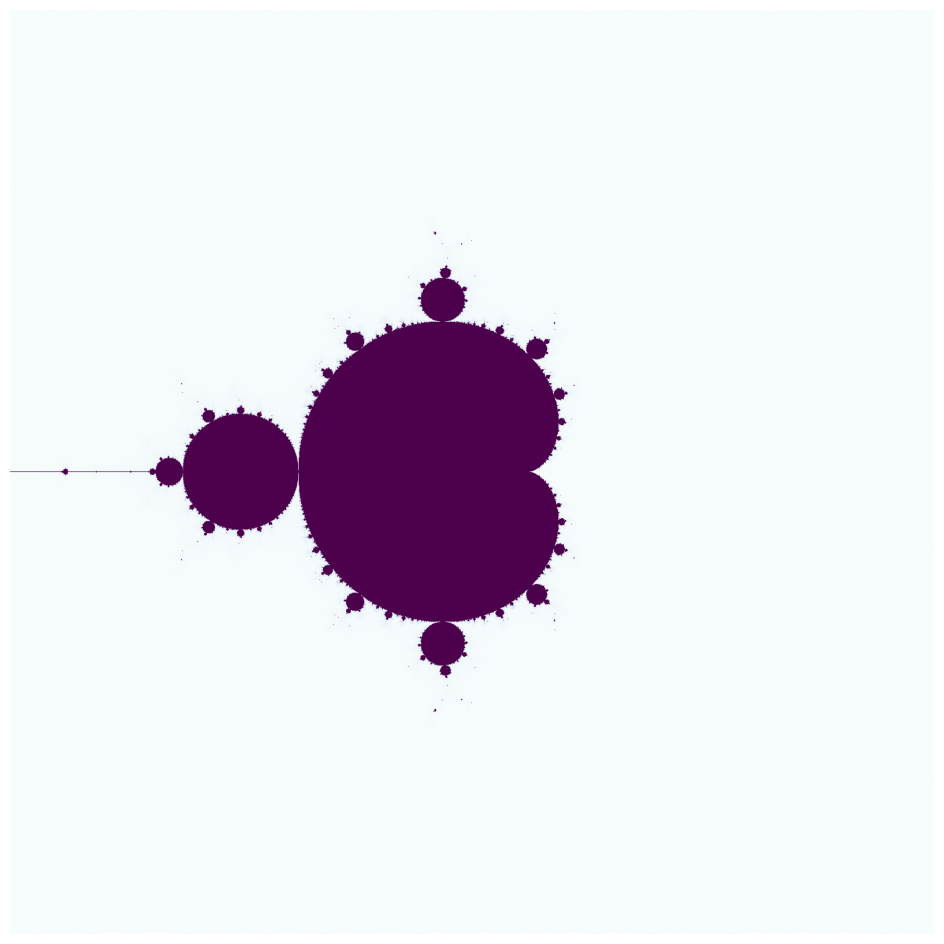

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import ipywidgets as w
from IPython.display import clear_output
from io import StringIO


data = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-04-17.1.csv')
area = np.zeros((1600, 1600))

scaling = 4 / 2.0

x = lambda r: int(((r + scaling)/(scaling * 2)) * 1599)
y = lambda i: int(((i + scaling)/(scaling * 2)) * 1599)

for idx, row in data.iterrows():
    area[x(row['r'])][y(row['i'])] = row['value']

fig = plt.figure()
fig.set_size_inches(12, 12)
ax = fig.add_subplot(1, 1, 1)
# # ax.get_figure().set_size_inches(7, 7)
# ax.spines['left'].set_position('center')
# ax.spines['bottom'].set_position('center')
# ax.spines['top'].set_color('none')
# ax.spines['right'].set_color('none')

ax.set_axis_off()
# ax.grid(linestyle='dotted')
# ax.locator_params(axis='x', nbins = 4)
# ax.locator_params(axis='y', nbins = 4)

plt.imshow(area.T, cmap = plt.colormaps['BuPu_r'])
plt.show()

# def run(b):
#     global uploader
#     render(pd.read_csv(StringIO("csv string")))

# uploader = w.FileUpload(multiple=False)
# # t = w.Text()
# run_button = w.Button(description='Run', icon='play')
# run_button.on_click(run)
# h_box = w.HBox([uploader, run_button])
# display(h_box)

----


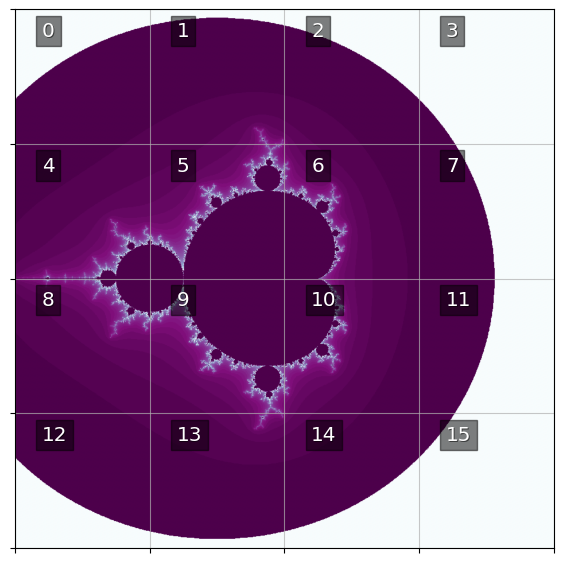

In [61]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as colors
from concurrent.futures import ThreadPoolExecutor, Future

executor = ThreadPoolExecutor(max_workers=None)

# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-03-27.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-03-27-1.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-06.1.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-13.3.csv') # deep zoom w. structure
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-18.2.csv') # too deep a zoom (blank field after an hour!)
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-20.1.csv') # zoom = 150_000 work-3.yml
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-22.1.csv')
# ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-05-22.2.csv')
ds = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/run0-2025-07-17.1.csv')


def addLabels(ax: plt.Axes):
    for row in range(0, 1000, 250):
        for column in range(0, 1000, 250):
            n = int((4 * (row / 1000)) + (16 * (column / 1000)))
            ax.text(x=row + 51, y= column + 51, s=str(n), color="#00000080", fontsize='x-large')
            ax.text(x=row + 50, y= column + 50, s=str(n), color="#ffffffff", fontsize='x-large', backgroundcolor = "#00000080")

def plotDs(ax: plt.Axes, ds: pd.DataFrame, decorators: list = []):
    ball = (1001, 1001)
    space = np.zeros(ball)

    df = ds.sort_values(['i', 'r'], ascending=True)
    # print(df.iloc[500000, :])

    # annotation_point = None
    # annotation_coords = -0.19821982198219823-1.1003100310031004j
    # annotation_ball = 1e-2
    # print(df.head())

    # Plotting by transforming coordinates
    min_r, max_r = np.min(df["r"]), np.max(df["r"])
    min_i, max_i = np.min(df["i"]), np.max(df["i"])

    conv_r = lambda x: ((ball[0] - 1) * (x - min_r)) / (max_r - min_r)
    conv_i = lambda x: ((ball[1] - 1) * (x - min_i)) / (max_i - min_i)

    # print(df.head())

    # scale = 10
    for entry in df.iterrows():
        # executor.submit(process, entry, conv_r, conv_i).add_done_callback(assignSpace)

        if (np.isnan(entry[1].r) or np.isnan(entry[1].i)):
            continue
        x, y = int(np.round(conv_r(entry[1].r))), int(np.round(conv_i(entry[1].i)))
        space[y][x] = entry[1].value % 50
        # y = np.abs(min_i) + entry[1].i
    print('----')
    # print(space[100][100])

    # # ax.get_figure().set_size_inches(7, 7)
    # ax.spines['left'].set_position('center')
    # ax.spines['bottom'].set_position('center')
    # ax.spines['top'].set_color('none')
    # ax.spines['right'].set_color('none')
    # print(annotation_point)
    ax.set_xticks([0, 250, 500, 750, 1000])
    ax.set_yticks([0, 250, 500, 750, 1000])
    # ax.grid(linestyle='dotted', which='both', alpha=0.7)
    ax.grid(linestyle='solid', which='both', alpha=0.7)
    # ax.locator_params(axis='x', nbins = 4)
    # ax.locator_params(axis='y', nbins = 4)

    # ax.annotate('x', xy=annotation_point)
    # ax.set_axis_off()
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # decorators
    for d in decorators:
        d(ax)

    intv = ((max_r - min_r) / 4)

    ax.imshow(space, cmap = 'BuPu')

fig = plt.figure()

fig.set_size_inches(7, 7)
ax = fig.add_subplot(1, 1, 1)

plotDs(ax, ds, [addLabels])

# cmap = colors.LinearSegmentedColormap.from_list('a', plt.get_cmap('bone_r')(np.linspace(.2, .4, 1000)))
# cmap = colors.LinearSegmentedColormap.from_list()

# plt.imshow(space, cmap = 'BuPu')#, norm=colors.Normalize(vmin=-1, vmax=5000))
#plt.show()


## Continuous Wavelet Transform of Signal Data

/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/matplotlib/contour.py:1364: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/matplotlib/contour.py:1365: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/numpy/ma/core.py:2892: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


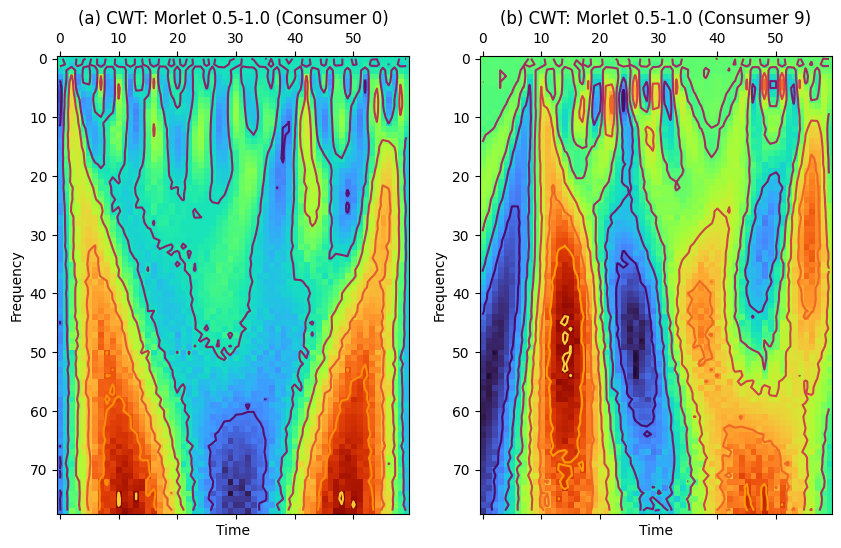

In [414]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt

perfData = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/Dwell Time-data-as-joinbyfield-2025-05-27 16_52_09.csv')
# coef, freq = pywt.cwt(perfData['{group="consumers-custom", instance="consumer-9:9180", job="experiment"}'][1200:1400], scales = np.arange(1, 50,.3), wavelet='morl')
data_region = perfData['{group="consumers-custom", instance="consumer-0:9180", job="experiment"}'][1217:1277]
data_region2 = perfData['{group="consumers-custom", instance="consumer-9:9180", job="experiment"}'][1217:1277]
coef, freq = pywt.cwt(data_region, scales = np.arange(1, 40,.5), wavelet='cmor0.5-1.0')
coef2, freq2 = pywt.cwt(data_region2, scales = np.arange(1, 40,.5), wavelet='cmor0.5-1.0')

# plt.plot(perfData['{group="consumers-custom", instance="consumer-9:9180", job="experiment"}'])
# plt.pcolormesh(coef, cmap='BuPu_r')
fig, [ax1, ax2]= plt.subplots(1, 2)
# fig.suptitle('Wavelet Analysis')
fig.set_size_inches(10, 7)
# ax1 = fig.add_subplot(1, 1, 1)
ax1.set_xlabel('Time')
ax1.set_ylabel('Frequency')
ax1.set_title('(a) CWT: Morlet 0.5-1.0 (Consumer 0)')
ax1.matshow(coef.real, cmap='turbo')
ax1.contour(coef, cmap='inferno')

ax2.set_xlabel('Time')
ax2.set_ylabel('Frequency')
ax2.set_title('(b) CWT: Morlet 0.5-1.0 (Consumer 9)')
ax2.matshow(coef2.real, cmap='turbo')
ax2.contour(coef2, cmap='inferno')

# ax.invert_yaxis()
plt.show()

# plt.contour(coef, cmap='BuPu_r')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pywt

# wavelet = pywt.ContinuousWavelet("cmor1.5-1.0")
wavelet = pywt.ContinuousWavelet("cmor0.5-1.0")
# wavelet = pywt.Wavelet('haar')

total_points = 200
psi, x = wavelet.wavefun(level=8, length=total_points)
fft = np.fft.fft(psi)
fig, ((plt1, plt2), (plt3, plt4)) = plt.subplots(2, 2)
fig.set_size_inches(10, 10)
fig.suptitle('Consumer-0 Fourier Analysis')
# plt1.figure(figsize=(10, 4))
plt1.plot(x, np.real(psi), label="real")
plt1.plot(x, np.imag(psi), label="imag", linestyle='--')
# plt1.title('Morlet (cmor) Wavelet')
# plt1.xlabel('Time')
# plt1.ylabel('Amplitude')
plt1.set_title('Wavelet')
plt1.legend()
plt1.grid(True)

plt2.plot(fft)
plt2.set_title('Wavelet FFT')

data = perfData[1217:1277]['{group="consumers-custom", instance="consumer-0:9180", job="experiment"}']
perfdata_fft = np.fft.rfft(data - np.mean(data)) # rfft removes symetries from a regular fft plot.

plt3.plot(data)
plt3.set_title('Data')

plt4.plot(perfdata_fft)
plt4.set_title('Data FFT')



: 

## Grand Tour Data Analysis
What follows the generation of subplots \[from the grand tour dataset\].

all threads have started...
----
----
thread t1 completed
----
----
thread t5 completed
----
thread t2 completed
thread t3 completed
thread t4 completed
done.


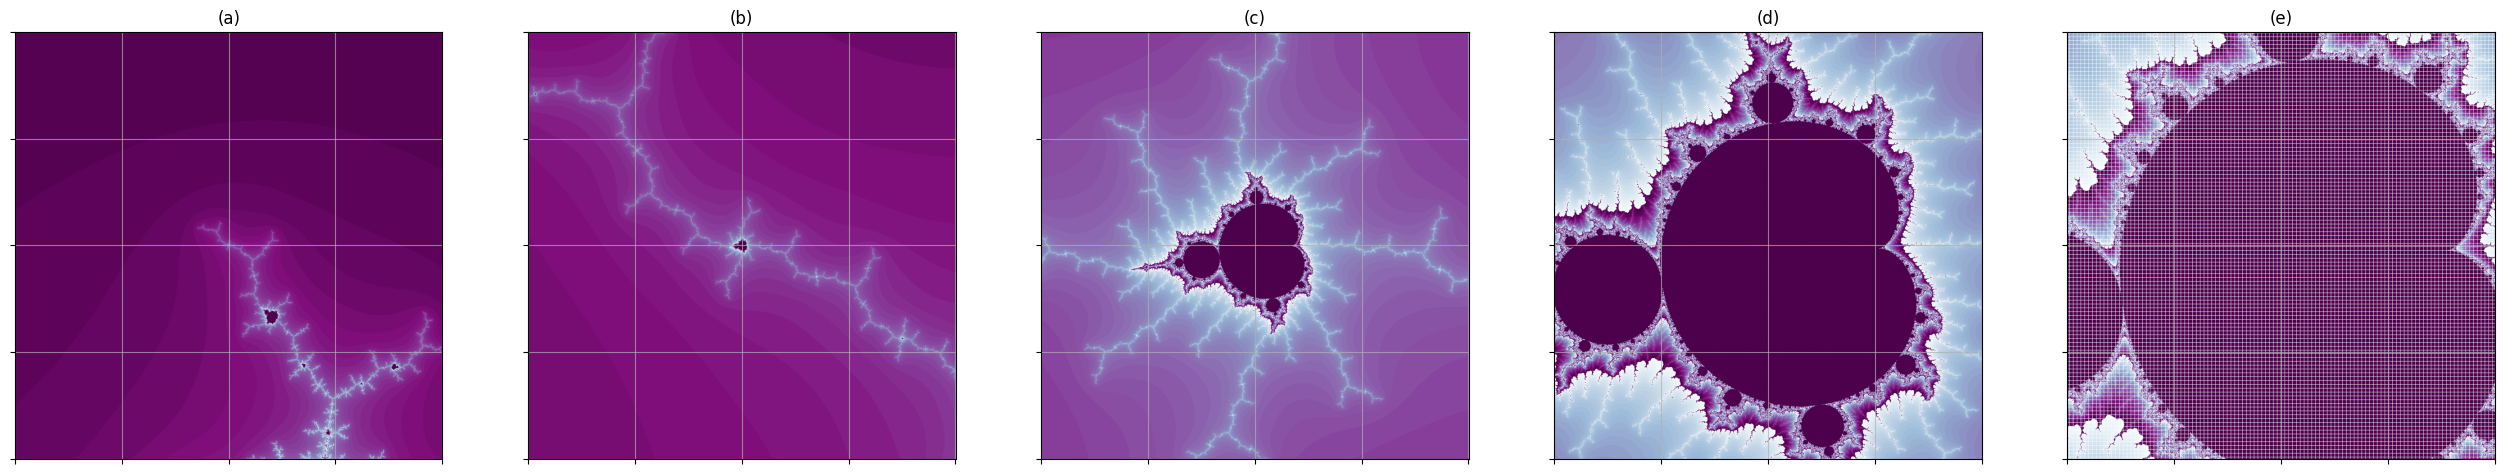

In [504]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# import threading
from threading import Thread
# from multiprocessing import Process

# try:
#     ds1.head()
#     ds2.head()
#     ds3.head()
# except NameError:
ds1 = ds2 = d3 = None
ds1, ds2, ds3, *doth = [
    pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/grandtour-data-20250529/run0-02b3c839-437d-4180-9e06-6577d5b3b4c9.csv'),        
    pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/grandtour-data-20250529/run0-8696741f-cfa1-4c0c-9172-d2a38d81a5fe.csv'),
    pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/grandtour-data-20250529/run0-57fc3e5e-4796-4109-b30d-7512f090d211.csv'),
    pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/Grandtour analysis files/grandtour-data-20250529/run0-b3d85364-3689-4827-bed1-29a989adbabc.csv'),
    pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/Grandtour analysis files/grandtour-data-20250529/run0-b7269106-5834-461d-9fce-4310d6a5e6db.csv'),

]
fig, ax = plt.subplots(1,5)
fig.set_size_inches(32, 16)

def runProcess(ax, ds, title):
    plotDs(ax, ds, [lambda p: p.set_title(title)])

threads = [
    # Process(target=runProcess, args=(ax[0][0], 'a'), name="p1")
    # Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(a)', loc='right') and p.set_title(loc='left', label=ds1['modifiedAt'][0])]), args=(ax[0], ds1),name="t1"),
    # Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(b)', loc='right') and p.set_title(loc='left', label=doth[1]['modifiedAt'][0])]), args=(ax[1], doth[1]),name="t5"),
    # Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(c)', loc='right') and p.set_title(loc='left', label=ds2['modifiedAt'][0])]), args=(ax[2], ds2),name="t2"),
    # Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(d)', loc='right') and p.set_title(loc='left', label=ds3['modifiedAt'][0])]), args=(ax[3], ds3),name="t3"),
    # Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(e)', loc='right') and p.set_title(loc='left', label=doth[0]['modifiedAt'][0])]), args=(ax[4], doth[0]),name="t4"),
    
    Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(a)', loc='center')]), args=(ax[0], ds1),name="t1"),
    Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(b)', loc='center')]), args=(ax[1], doth[1]),name="t5"),
    Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(c)', loc='center')]), args=(ax[2], ds2),name="t2"),
    Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(d)', loc='center')]), args=(ax[3], ds3),name="t3"),
    Thread(target=lambda ax, ds: plotDs(ax, ds, [lambda p: p.set_title('(e)', loc='center')]), args=(ax[4], doth[0]),name="t4"),
]

for t in threads:
    t.start()
print("all threads have started...")
for t in threads:
    t.join()
    print(f"thread {t.name} completed")
print("done.")

# plotDs(ax[0][0], ds1)
# plotDs(ax[0][1], ds2)
# plotDs(ax[0][2], ds3)


In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import ipywidgets as widgets
from datetime import datetime
# import sys
# !pip install ipympl
%matplotlib inline

# gtData = pd.read_csv('./Dwell Time-data-as-joinbyfield-2025-05-27 16_52_09.csv')
# gtData = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/perf-data-2025-07-22T16:08:21Z-7day.csv')
gtData = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/perf-data-2025-07-18T13:16:45Z-14day.csv')
# gtData = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/perf-data-2025-07-18T13:16:45Z-14day.csv')
gtData = gtData.drop(['Unnamed: 0'], axis=1)
gtData.set_index('Timestamp')
gtData.reset_index()


def run(lh: int, rh: int):
    global gtData
    # plt.cla()
    # plt.clf()
    fig = plt.figure()
    fig.set_size_inches(16, 16)
    ax = fig.subplots(3, 1)

    # lh, rh = 120, 260
    # lh, rh = 0, len(gtData)
    # lh, rh = 8150, len(gtData)
    # lh, rh = 4800, 4900
    # lh, rh = 7420, 7470
    # t = slice(gtData['Timestamp'], lh, rh)

    runs = []
    means = []
    for c in filter(lambda name: name not in ('Timestamp', 'Time'), gtData.columns):
        # print(gtData.iloc[:,[0,1]])
        run = gtData[c].iloc[lh:rh]
        # run = gtData.iloc[lh:rh,[0, 1]]
        means.append(run.mean())
        runs.append(run)
        # ax[0].stairs(run, alpha=0.2, fill=False)
        ax[0].plot(run, alpha=0.4, drawstyle='default', solid_joinstyle='round', linestyle='-', solid_capstyle='round')#, marker='x')#, drawstyle='steps')

    m10 = int(np.abs(lh -rh) / 10)
    ax[0].set_title('Time series plot')
    ax[0].set_xticks(range(lh, rh, m10))
    ax[0].legend([f"c/{n}" for n in range(0, 16)])
    ax[0].grid(alpha=0.2)
    ax[0].set_facecolor('#eeeeeeff')
    ax[0].set_xticklabels(map(lambda n: datetime.fromtimestamp(gtData['Timestamp'][n]).strftime('%H:%M:%S'), range(lh, rh, m10)), rotation=90)
    # ax[0].set_xticklabels(map(lambda n: datetime.fromtimestamp(gtData['Timestamp'][n]).strftime('%Y-%m-%d %H:%M:%S'), range(lh, rh, m10)), rotation=90)
    secx0 = ax[0].secondary_xaxis('top', functions=(lambda x: x, lambda x: x))
    secx0.set_xticks(range(lh, rh, m10))
    # secx0.set_xticklabels([x for x in range(0, len(gtData['Timestamp']))], rotation=90)

    ax[1].set_title('Time series Matrix Plot')
    m = ax[1].matshow(runs, cmap='inferno', aspect=2.0)
    ax[1].set_yticks(range(0, 16))
    ax[1].set_yticklabels(map(lambda n: f"consumer-{n}", range(0, 16)))
    # ax[1].grid()
    plt.colorbar(m, ax=ax[1], label='Time (ms)')

    sd = np.mean(means)
    # mcol = [{m > sd: 'red', m <= sd: 'blue'}[True] for m in means]
    cmap = plt.get_cmap('turbo')
    mcol = [cmap(m / max(means)) for m in means]
    ax[2].set_title('Mean Performance Time')
    ax[2].set_xlabel('Consumer')
    ax[2].set_ylabel('Time (ms)')
    d = ax[2].bar(range(0, len(means)), means, color=mcol)
    ax[2].set_xticks(range(0, 16))
    ax[2].set_xticklabels(map(lambda n: f"consumer-{n}", range(0, 16)), rotation=45)
    plt.colorbar(plt.matshow([[0, max(means)]], cmap=cmap), ax=ax[2], label='Time (ms)')

    fig.tight_layout()

    plt.show()

def test(b):
    try:
        run(int(minBox.value), int(maxBox.value))
        print('here')
    except Exception:
        print("failed")


# minBox = widgets.Text(value="0", description="Min T:")
# maxBox = widgets.Text(value=str(len(gtData)), description="Max T:")

# def on_value_change(change):
#     global lr_slider
#     minBox.value, maxBox.value = map(str, lr_slider.value)

# def on_minmaxbox_change(change):
#     global minBox, maxBox, lr_slider
#     if (int(minBox.value) < int(maxBox.value)):
#         lr_slider.value = tuple(map(int, (minBox.value, maxBox.value)))

# lr_slider = widgets.IntRangeSlider(
#     value = [0, len(gtData)],
#     min = 0, max=len(gtData),
#     description="Time:",
#     orientation="horizontal",
#     readout=True,
#     readout_format='1d'
# )

notes = widgets.Label(f"Min value = 0, max value={maxBox.value}")
# lr_slider.observe(handler = on_value_change)
# minBox.observe(handler = on_minmaxbox_change)
# maxBox.observe(handler = on_minmaxbox_change)

# run_btn = widgets.Button(description="Run", icon="play")
widgets.interact(run, lh = widgets.IntSlider(value=0, min = 0, max=len(gtData)), rh = widgets.IntSlider(value=len(gtData), min = 0, max =len(gtData)))


# run_btn.on_click(test)


# run_btn.on_click(lambda e: run(int(minBox.value), int(maxBox.value)))
# display(notes, minBox, maxBox, lr_slider, run_btn)


interactive(children=(IntSlider(value=0, description='lh', max=10081), IntSlider(value=10081, description='rh'…

<function __main__.run(lh: int, rh: int)>

midway for test-0 = (-0.19871950000000002-1.099977j)
midway for test-1 = (-0.19838650000000002-1.099977j)
midway for test-2 = (-0.198053-1.099977j)
midway for test-3 = (-0.19771950000000002-1.099977j)
midway for test-4 = (-0.19871950000000002-1.10031j)
midway for test-5 = (-0.19838650000000002-1.10031j)
midway for test-6 = (-0.198053-1.10031j)
midway for test-7 = (-0.19771950000000002-1.10031j)
midway for test-8 = (-0.19871950000000002-1.100643j)
midway for test-9 = (-0.19838650000000002-1.100643j)
midway for test-10 = (-0.198053-1.100643j)
midway for test-11 = (-0.19771950000000002-1.100643j)
midway for test-12 = (-0.19871950000000002-1.100977j)
midway for test-13 = (-0.19838650000000002-1.100977j)
midway for test-14 = (-0.198053-1.100977j)
midway for test-15 = (-0.19771950000000002-1.100977j)


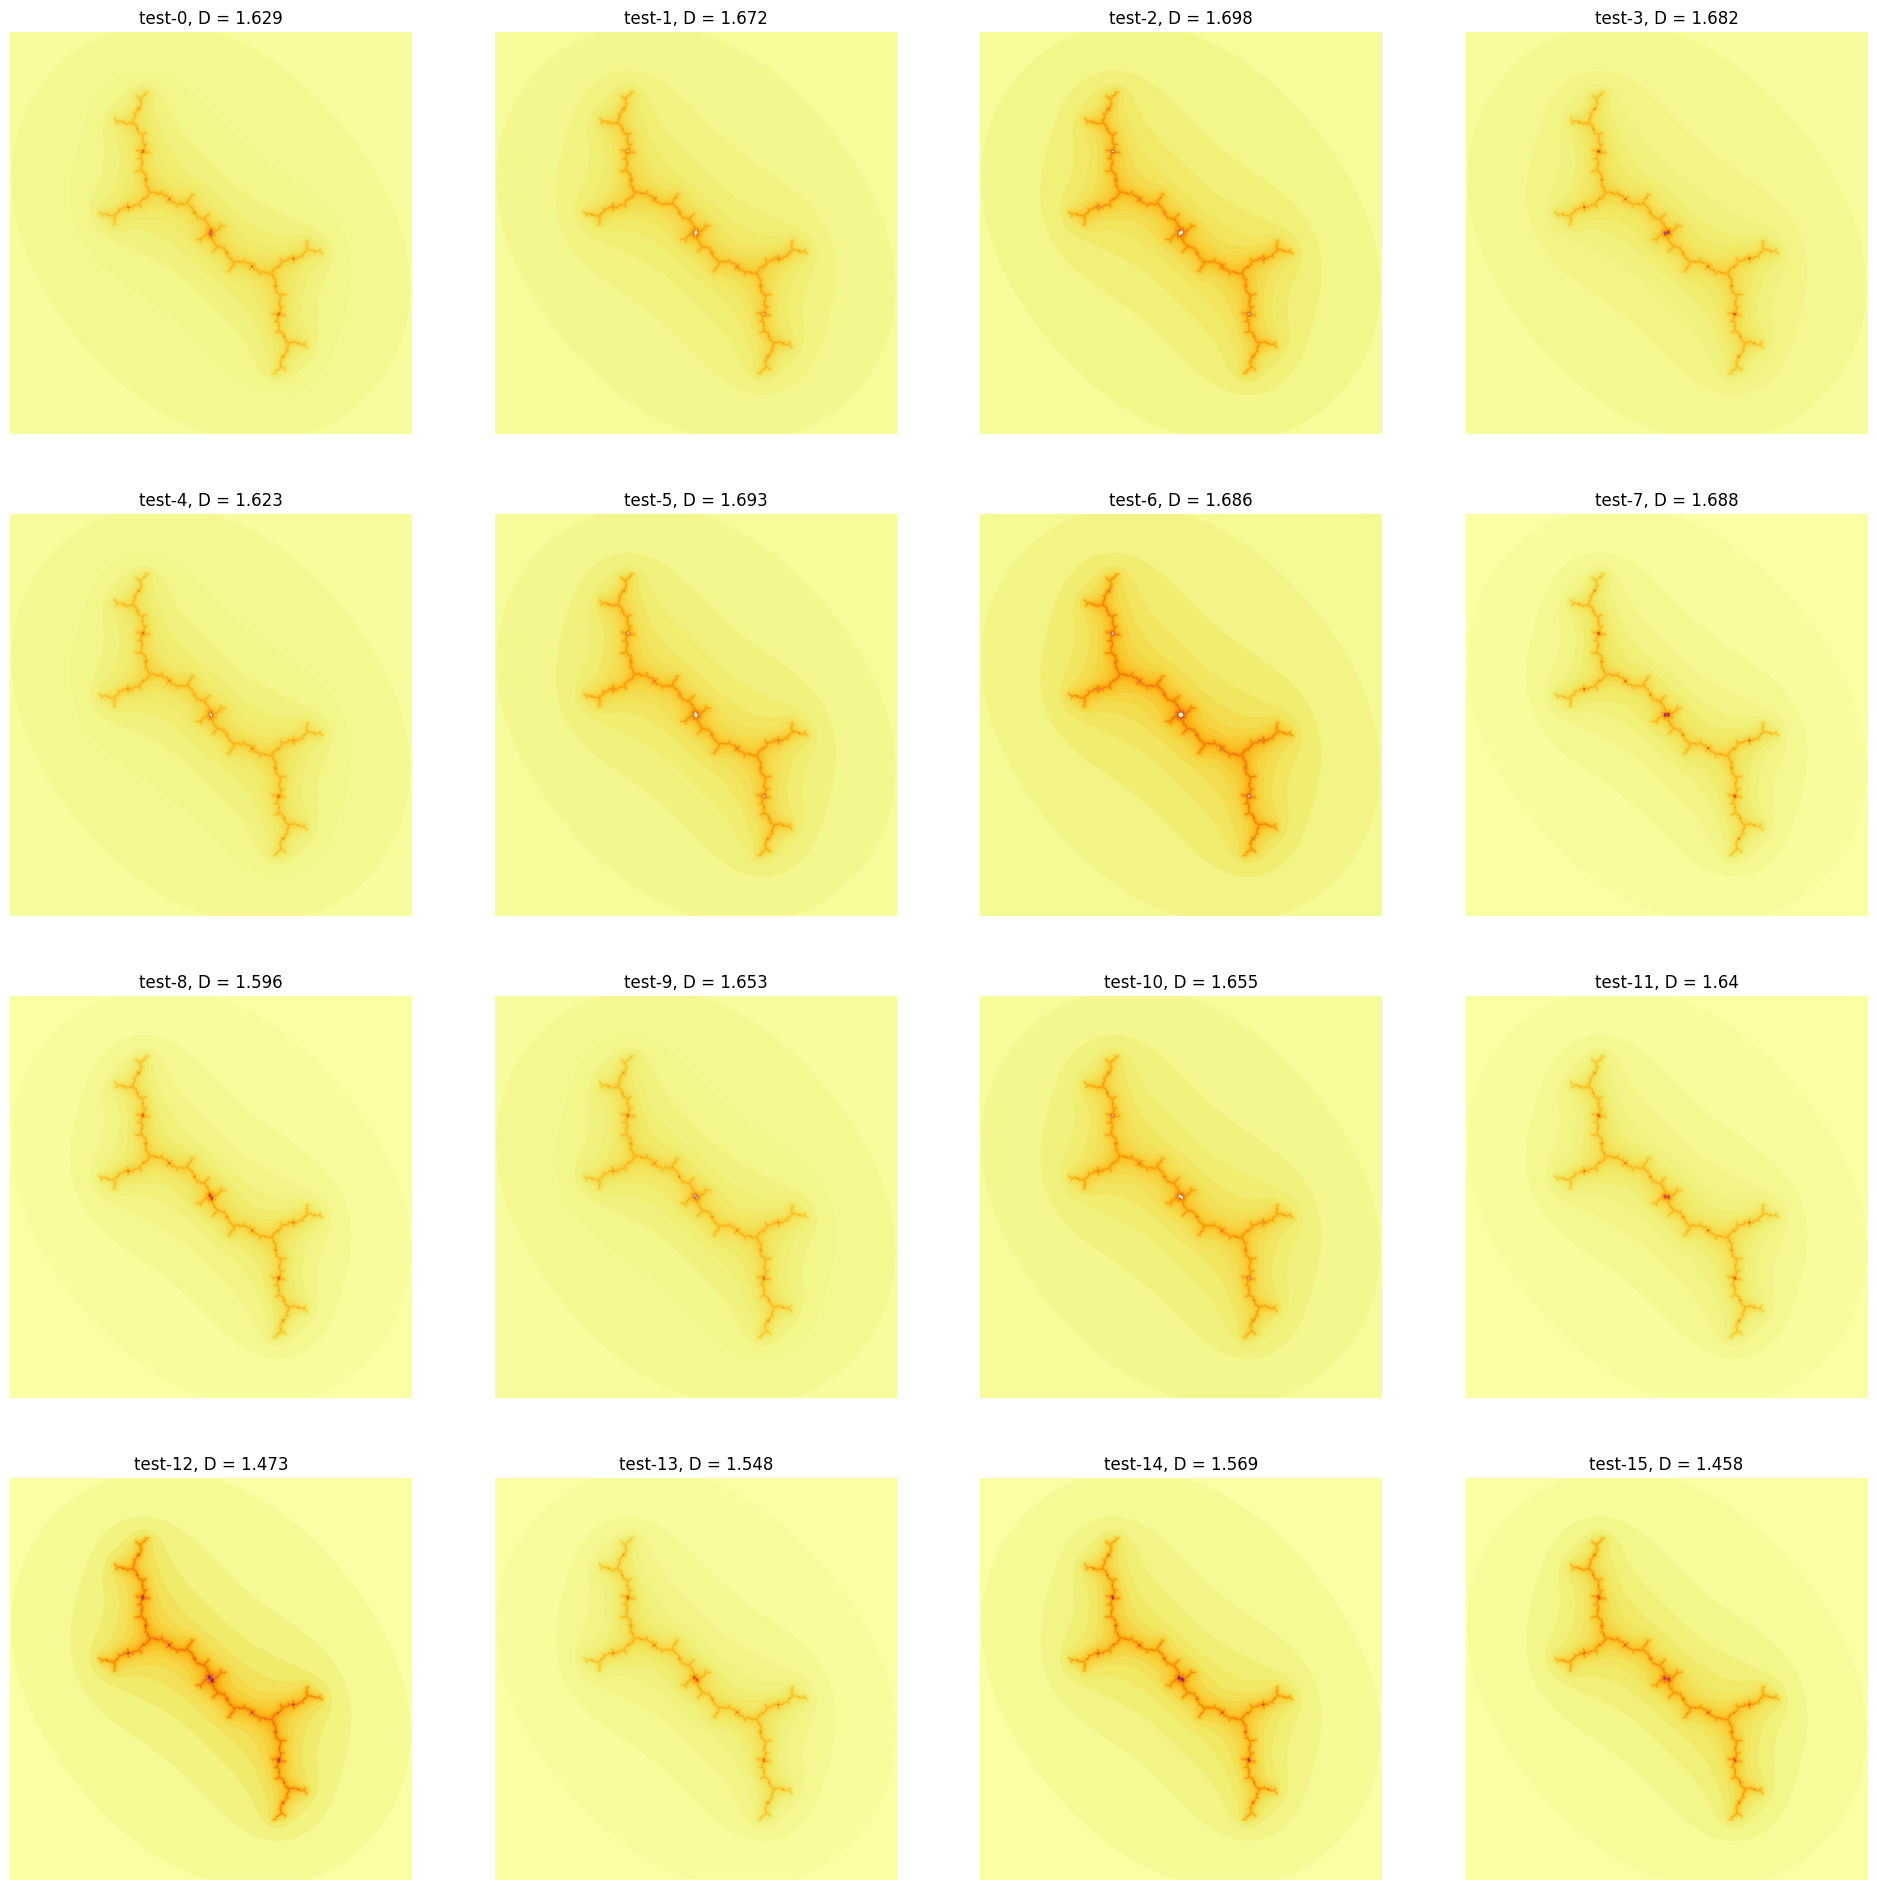

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [85]:
def plot_julia(ds: pd.DataFrame, topic: str, ax: plt.Axes, mean=None):
    t0 = ds.loc[lambda df: df.fromTopic == topic]
    np.min(t0.r)
    np.min(t0.i)
    lh, rh = np.complex128(np.min(t0.r), np.min(t0.i)), np.complex128(np.max(t0.r), np.min(t0.i))
    # lh, rh = np.sum(t0.r), np.median(t0.i)
    #t0.r.count()


    interval = np.abs(lh - rh) / t0.r.count()

    midway = lh + (interval / 2) * t0.r.count()
    print(f"midway for {topic} = {midway}")

    area = np.zeros((1001, 1001))

    bounds_r = np.linspace(-2, 2, 1000)
    bounds_i = np.linspace(-2, 2, 1000)

    r, i = np.meshgrid(bounds_r, bounds_i)
    grid = r + 1j * i

    blowup = 4.0
    box_threshold = 30
    nr = 0
    for z in grid.flatten():
        m = z
        x = ((2 + z.real) / 4) * 1000
        y = ((2 + z.imag) / 4) * 1000
        for iteration in range(0, 100):
            m = np.pow(m, 2) + midway
            if (np.abs(m) >= blowup):
                area[int(x)][int(y)] = iteration
                break
            area[int(x)][int(y)] = -1
        if (box_threshold <= area[int(x)][int(y)] or area[int(x)][int(y)] == -1):
            nr += 1

    dimension = np.round(np.log(nr)/np.log(np.sqrt(1000)), 3)

    plt3 = plt.figure()
    ax.imshow(area, cmap='inferno_r')
    mean_text = {True: f", Mean Perf = {mean}", False: ""}[mean != None]
    ax.set_title(f"{topic}, D = {dimension}{mean_text}")
    ax.set_axis_off()

# Generate Gallery of Julia Sets and box counts
fig = plt.figure()
fig.set_size_inches(24, 24)
# fig.suptitle('DS3 center Julias, approximate dimensions, and average performance')
ax = fig.subplots(4, 4)
for x in range(0, 4):
    for y in range(0, 4):
        # Plot julia set
        try:
            plot_julia(ds3, f"test-{(4 * x) + y}", ax[x][y], np.round(means[(4 * x) + y], 2))
        except NameError:
            plot_julia(ds3, f"test-{(4 * x) + y}", ax[x][y])
        # Box count algorihtm
        



### Performance Evaluation for Gran Rtour.

: 

# Hausdorff Illustration

In [ ]:
from matplotlib import pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 4)
ax[0].set_xticks([0, 1, 2])
ax[0].set_yticks([0, 1, 2])
ax[0].grid(True)
ax[0].add_patch(plt.Circle((1, 1), 1))
ax[0].set_title(f'(a) d = {np.log(4)/np.log(1/2)}')

ax[1].set_xticks([0, 1, 2, 3, 4])
ax[1].set_yticks([0, 1, 2, 3, 4])
ax[1].add_patch(plt.Circle((2, 2), 2))
ax[1].grid(True)
ax[1].set_title(f'(b) d = {np.log(16)/np.log(1/4)}')


ax[2].set_xticks(np.arange(0, 9))
ax[2].set_yticks(np.arange(0, 9))
ax[2].add_patch(plt.Circle((4, 4), 4))
ax[2].grid(True)
ax[2].set_title('c')
ax[2].set_title(f'(c) d = {np.log(60)/np.log(1/8)}')

ax[3].set_xticks(np.arange(0, 17))
ax[3].set_yticks(np.arange(0, 17))
ax[3].add_patch(plt.Circle((8, 8), 8))
ax[3].grid(True)
ax[3].set_title('c')
ax[3].set_title(f'(d) d = {np.log(256 - (6 * 4))/np.log(1/16)}')


fig.set_size_inches(16, 4)

plt.show()

: 

: 

### 2026-01-07

Here, a biorthoganl discrete wavelet transform compresses the time series data (signal) into 3 levels of decomposition for the avaerage performance profile for each node operating on the Mandelbrot set operating on $[-2, 2] \times i[-2, 2]$ at a resolution of $1600 \times 1600$ with 1000 iterations.

Any other consumer's run information can be represented in a likewise manner and the differences in either the point data of the coefficients or some other metric like variance or standard deviation could imply a certain level of close resemblence between each node. By getting a singular key metric, all nodes can be placed into a square matrix for comparison (even probabilistically).

Let $E$ be the 8-run matrix of variance and $C$ be a consumer run perhaps:

$$
\Delta = E - C
$$

['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7', 'db8', 'db9', 'db10', 'db11', 'db12', 'db13', 'db14', 'db15', 'db16', 'db17', 'db18', 'db19', 'db20', 'db21', 'db22', 'db23', 'db24', 'db25', 'db26', 'db27', 'db28', 'db29', 'db30', 'db31', 'db32', 'db33', 'db34', 'db35', 'db36', 'db37', 'db38', 'dmey', 'haar', 'rbio1.1', 'rbio1.3', 'rbio1.5', 'rbio2.2', 'rbio2.4', 'rbio2.6', 'rbio2.8', 'rbio3.1', 'rbio3.3', 'rbio3.5', 'rbio3.7', 'rbio3.9', 'rbio4.4', 'rbio5.5', 'rbio6.8', 'sym2', 'sym3', 'sym4', 'sym5', 'sym6', 'sym7', 'sym8', 'sym9', 'sym10', 'sym11', 'sym12', 'sym13', 'sym14', 'sym15', 'sym16', 'sym17', 'sym18', 'sym19', 'sym20']
Wavelet bior3.9
  Family name:    

/Users/rodericktimmerman/workspace/testbed/.venv/lib/python3.13/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 3 is too high: all coefficients will experience boundary effects.
  warnings.warn(


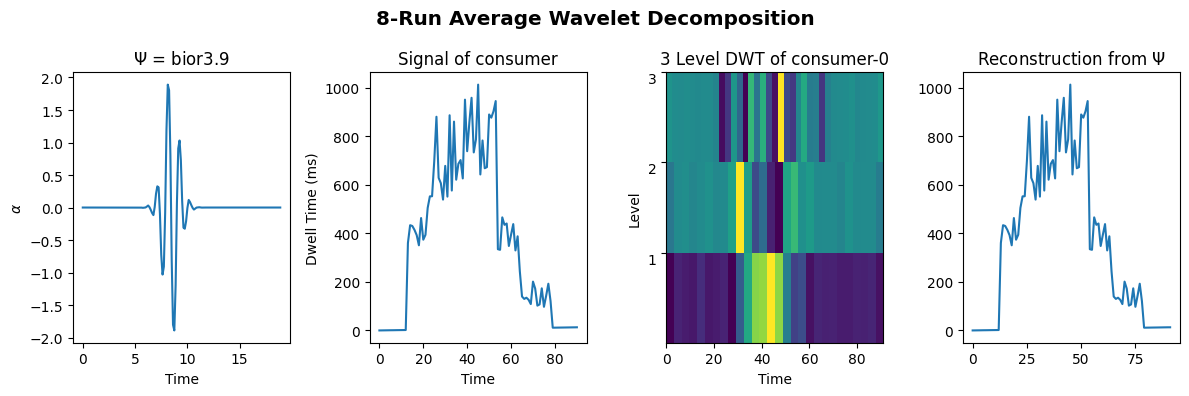

In [643]:
import pywt
from matplotlib import pyplot as plt
import pandas as pd

print(pywt.wavelist(kind = 'discrete'))

wavelet = pywt.Wavelet('bior3.9')
print(wavelet)
# print(wavelet.wavefun())
# [phi, psi, x] = wavelet.wavefun(level=8)
[phi, psi, x, *extra] = wavelet.wavefun(level=3)
fig, ax = plt.subplots(1, 4)
fig.set_size_inches(12, 4)
ax[0].plot(extra[1], psi)
ax[0].set_title('$\\Psi$ = bior3.9')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('$\\alpha$')

allruns = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/average_loads_for_dt_2025-04-21-1657-25.csv')

# print(allruns.loc[:]['consumer-0'])
consumer_name = 'consumer-0'
signal = allruns[:][consumer_name]
ax[1].plot(signal)
ax[1].set_title('Signal of consumer')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Dwell Time (ms)')

cA, cD = pywt.dwt(signal, wavelet=wavelet)
coeffs = pywt.wavedec(signal, wavelet=wavelet, level = 3)
for i, c in enumerate(coeffs):
    extent = [0, len(signal), i, i + 1]
    ax[2].imshow(c.reshape(1, -1), extent = extent, cmap='viridis', aspect='auto', interpolation='nearest')

ax[2].set_ylim(0, 3)
ax[2].set_title(f'3 Level DWT of {consumer_name}')
ax[2].set_xlabel('Time')
ax[2].set_ylabel('Level')
ax[2].set_yticks((1,2,3))
ax[2].tick_params(axis='x', which='minor', tick1On=False, tick2On=False)
for l in ax[2].get_yticklabels():
    l.set_verticalalignment("top")

print(wavelet)
i = pywt.idwt(cA, cD, wavelet=wavelet)

# filtered coeeficients (here we only use levels 0 and 3)
fcoeffs = [coeffs[0],np.zeros_like(coeffs[1]), coeffs[2], np.zeros_like(coeffs[3])]
# fcoeffs = [np.zeros_like(coeffs[0]),np.zeros_like(coeffs[1]), coeffs[2], np.zeros_like(coeffs[3])]

i = pywt.waverec(coeffs, wavelet)

ax[3].plot(i)
ax[3].set_title('Reconstruction from $\\Psi$')
# ax[3].legend(range(1,4))
print(cD[0])
# ax[2].plot(cA, cD[0])
fig.suptitle('8-Run Average Wavelet Decomposition', fontsize='x-large', fontweight='bold')
fig.set_tight_layout(True)
plt.show()

* 8 Run Mandelbrot set dataset fiile: `Dwell Time-data-as-joinbyfield-2025-04-21 16_57_25.csv` see `../../PrometheusDataAnalysis/average_loads_for_dt_2025-04-21-1657-25.csv` for the averaging according to correlation (band-pass filter analysis).

### 2026-01-08
* Establish a matrix for comparison, let's start with a matrix of variance (or standard deviation) for all consumers over the set for the mother wavelet $A$.

[[68.05 59.84 62.97 52.74]
 [58.55 37.84 54.96 55.19]
 [65.82 66.74 57.92 47.87]
 [46.63 52.08 70.73 52.53]]


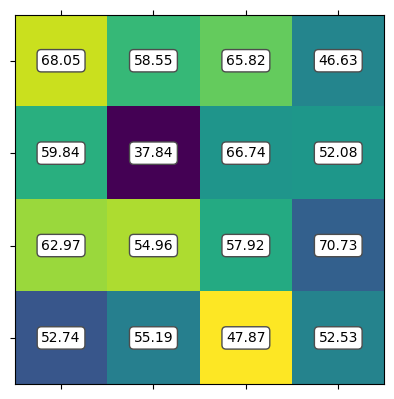

In [676]:
# Run the previous code block!
import numpy as np
import matplotlib.pyplot as plt


consumer_outputs = allruns.iloc[:,1:]
# print(len(consumer_outputs.columns))

# list of variances (alternative could be to use standard deviation (std))
def getCoeffs(signal):
    cA, cD = pywt.dwt(signal, wavelet=wavelet)
    return cD

v = list(map(lambda i: getCoeffs(consumer_outputs.iloc[:, i]).std(), range(0, len(consumer_outputs.columns))))

# a 4x4 matrix representation:
A = np.array(v).reshape(4, 4)
print(np.array([a.round(2) for a in A]))

fig, ax = plt.subplots()
xs, ys = A.shape
ax.matshow(A, cmap='viridis')
[l.set_visible(False) for l in ax.axes.get_xticklabels()]
[l.set_visible(False) for l in ax.axes.get_yticklabels()]

#, extent=[0, xs, ys, 0]


for (i, j), z in np.ndenumerate(A):
    ax.text(i, j, '{:0.2f}'.format(z), ha='center', va='center', bbox=dict(boxstyle='round', facecolor='white', edgecolor='0.3'))




* Variance of differences between two vectors: $D = A - B$, and then the vairance of the entries in the difference matrix all at once. The matrix norm may be useful but isn't immediately good at picking up changes at scale &#x2713;
* Next up let's do the variance one of the tour matrices for comparison to the 8-run matrix (as above).

run 1
[[178.39706226 211.58199269 217.67860672 177.34534334]
 [180.99820852 168.54332529 181.73086355 222.00726468]
 [327.39340426 140.01195213 242.94666366 177.34700925]
 [170.05802378 196.20363826 217.31874321 216.05981432]]
D var = 39.26311248359957
[[1.         0.32965372]
 [0.32965372 1.        ]]
Pearson Correlation Coefficient (PCC) of D = 0.3296537214547519
Spearman Rank: SignificanceResult(statistic=np.float64(0.36764705882352944), pvalue=np.float64(0.1612323576755899))
-------
run 2
[[207.34528609 204.36888961 189.50358975 221.01233019]
 [170.70541227 194.59350631 185.15350946 206.15723898]
 [202.23509771 185.90172828 195.65907245 177.80099346]
 [159.70477721 164.83168826 211.19017189 204.12472631]]
D var = 16.050299639342605
[[1.         0.35320555]
 [0.35320555 1.        ]]
Pearson Correlation Coefficient (PCC) of D = 0.3532055478908496
Spearman Rank: SignificanceResult(statistic=np.float64(0.4558823529411765), pvalue=np.float64(0.07594549116741177))
-------
run 3
[[178.324

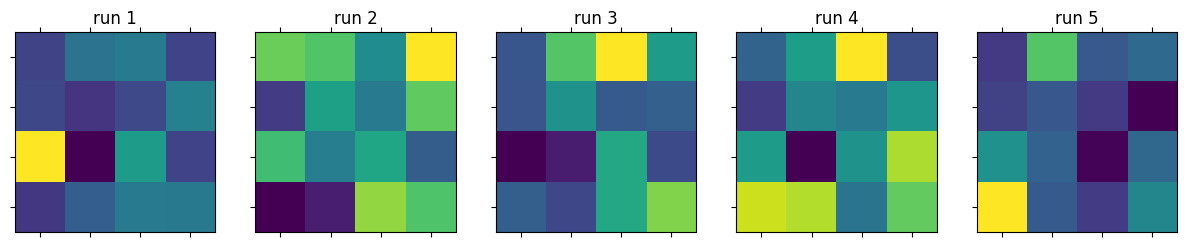

In [675]:
import numpy as np
from scipy.stats import spearmanr

# gt_rundata = pd.read_csv('/Users/rodericktimmerman/workspace/PrometheusDataAnalysis/Grandtour analysis files/Dwell Time-data-as-joinbyfield-2025-05-27 16_52_09.csv')
perfData.head()

# run locations
runs = {
    'run 1': perfData.iloc[118:222,1:], # run 1
    'run 2': perfData.iloc[289:404,1:], # run 2
    'run 3': perfData.iloc[476:591,1:], # run 3
    'run 4': perfData.iloc[650:765,1:], # run 4
    'run 5': perfData.iloc[845:920,1:]  # run 5
}

fig, ax = plt.subplots(1, 5)
nn = 0
for k in runs.keys():
    print(f"{k}")
    run = runs[k]
    v = list(map(lambda i: getCoeffs(run.iloc[:, i]).std(), range(0, len(run.columns))))

    B = np.array(v).reshape(4,4)
    print(B)

    # calculate variance
    D = A - B
    # s2 = np.vectorize(lambda d: np.pow(d - D.mean(), 2))
    # print(s2(D).sum() / 16.0)
    print(f"D var = {D.std()}")
    # Pearson Product-moment Coefficents
    pearson_coeff = np.corrcoef(A.flatten(), B.flatten())
    print(pearson_coeff)

    # pearson's coeff
    print(f"Pearson Correlation Coefficient (PCC) of D = {pearson_coeff[0][1]}")

    # sspearman rank (r)
    print(f"Spearman Rank: {spearmanr(A.flatten(), B.flatten())}")
    print('-------')
    ax[nn].matshow(B)
    ax[nn].set_title(k)
    [l.set_visible(False) for l in ax[nn].get_xticklabels()]
    [l.set_visible(False) for l in ax[nn].get_yticklabels()]

    nn += 1

fig.set_size_inches(15, 4)
plt.show()

# consumer_outputs 